In [3]:
from typing import List, Tuple, Dict, Any
import h5py

In [4]:
data_path: str = '/mnt/d/Downloads/Senior_Thesis/INSTANCE/Instance_sample_dataset_v3/data/Instance_events_gm_10k.hdf5'
f = h5py.File(data_path, "r")

f_keys = list(f.keys())

In [5]:
def print_structure(name, obj):
    print(name)

f.visititems(print_structure)

data
data/11030611.IV.OFFI..HH
data/11030611.IV.PIEI..HH
data/11030611.IV.PIEI..HN
data/11030611.IV.RM33..EH
data/11030611.IV.RM33..HN
data/11030611.IV.SEF1..HN
data/11030611.IV.SNTG..HH
data/11030611.IV.SNTG..HN
data/11030611.IV.SSFR..HH
data/11030611.IV.SSFR..HN
data/11030611.IV.SSM1..HN
data/11030611.IV.T0110..HH
data/11030611.IV.T1201..HN
data/11030611.IV.T1202..EH
data/11030611.IV.T1204..EH
data/11030611.IV.T1211..EH
data/11030611.IV.T1211..HN
data/11030611.IV.T1212..EH
data/11030611.IV.T1212..HN
data/11030611.IV.T1213..EH
data/11030611.IV.T1213..HN
data/11030611.IV.T1215..EH
data/11030611.IV.T1215..HN
data/11030611.IV.T1216..EH
data/11030611.IV.T1216..HN
data/11030611.IV.T1217..EH
data/11030611.IV.T1217..HN
data/11030611.IV.T1218..EH
data/11030611.IV.T1218..HN
data/11030611.IV.T1219..EH
data/11030611.IV.T1219..HN
data/11030611.IV.T1220..EH
data/11030611.IV.T1220..HN
data/11030611.IV.T1221..EH
data/11030611.IV.T1221..HN
data/11030611.IV.T1241..EH
data/11030611.IV.T1241..HN
data/11

In [9]:
waveforms = f[f_keys[0]]

print([d for d in dir(waveforms)])

['_MutableMapping__marker', '__abstractmethods__', '__bool__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__setattr__', '__setitem__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_d', '_e', '_get', '_id', '_ipython_key_completions_', '_lapl', '_lcpl', 'attrs', 'build_virtual_dataset', 'clear', 'copy', 'create_dataset', 'create_dataset_like', 'create_group', 'create_virtual_dataset', 'file', 'get', 'id', 'items', 'keys', 'move', 'name', 'parent', 'pop', 'popitem', 'ref', 'regionref', 'require_dataset', 'require_group', 'setdefault', 'update', 'values', 'visit', 'visit_links', 'visitit

In [16]:
for val in waveforms.values():
    print(val[0].shape)
    break

(12000,)


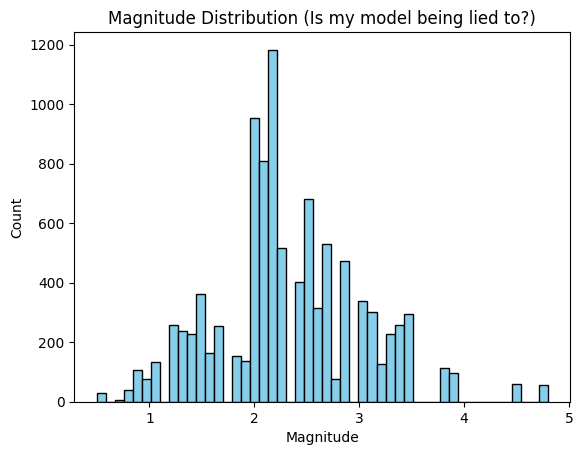

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

csv_path: str = "/mnt/d/Downloads/Senior_Thesis/INSTANCE/Instance_sample_dataset_v3/metadata/metadata_Instance_events_10k.csv"
df = pd.read_csv(csv_path)
plt.hist(df['source_magnitude'], bins=50, color='skyblue', edgecolor='black')
plt.title("Magnitude Distribution (Is my model being lied to?)")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.show()


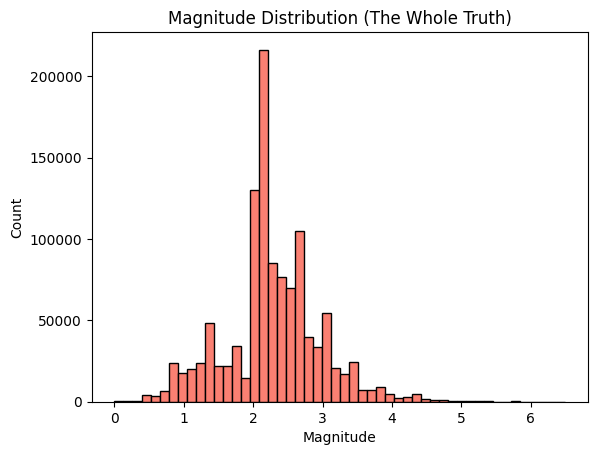

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

csv_path = "/mnt/d/Downloads/Senior_Thesis/INSTANCE/metadata_Instance_events_v3.csv.bz2"

df = pd.read_csv(csv_path, compression='bz2', usecols=['source_magnitude'])

plt.hist(df['source_magnitude'].dropna(), bins=50, color='salmon', edgecolor='black')

plt.title("Magnitude Distribution (The Whole Truth)")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.show()

In [3]:
import pandas as pd

# Assuming you already loaded your df. 
# (Drop the `usecols` from before if you actually need the other columns to fetch the waveforms later)

# 1. Grab M1.0 to 2.99 and pick 5k
low_mag = df[(df['source_magnitude'] >= 1.0) & (df['source_magnitude'] < 3.0)]
low_sampled = low_mag.sample(n=5000, random_state=42)

# 2. Grab M3.0 to 4.99 and pick 5k
mid_mag = df[(df['source_magnitude'] >= 3.0) & (df['source_magnitude'] < 5.0)]
mid_sampled = mid_mag.sample(n=5000, random_state=42)

# 3. Hoard every single M5.0+
high_mag = df[df['source_magnitude'] >= 5.0]

# Mash them all together
balanced_df = pd.concat([low_sampled, mid_sampled, high_mag])

# CRITICAL: Shuffle the dataframe. 
# If you don't do this, your model sees 5k lows, then 5k mids, then highs, and will get totally confused.
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Sanity check
print("Dataset size:", len(balanced_df))
print(balanced_df['source_magnitude'].describe())

Dataset size: 11757
count    11757.000000
mean         3.169559
std          1.189299
min          1.000000
25%          2.300000
50%          3.000000
75%          3.600000
max          6.500000
Name: source_magnitude, dtype: float64


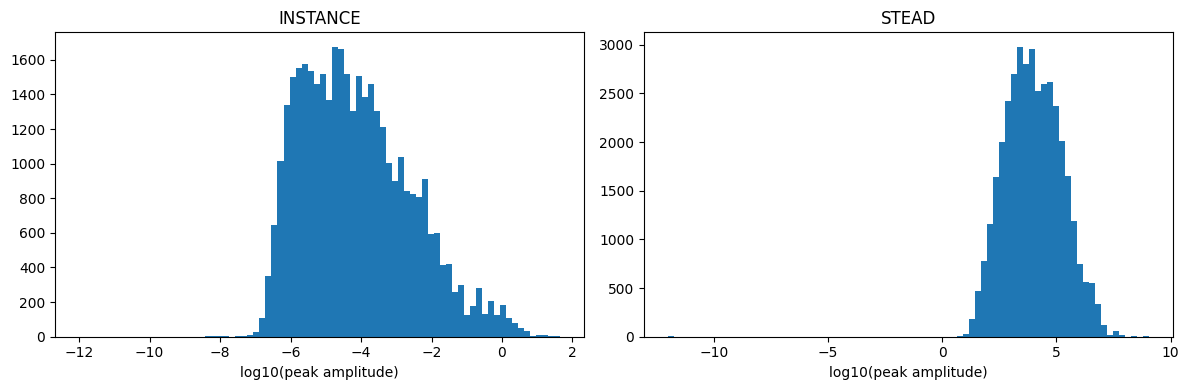

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

events = np.memmap("/home/aidar/study/senior_thesis/data/unified/waveforms_events.bin", dtype="float32", mode="r")
meta   = pd.read_csv("/home/aidar/study/senior_thesis/data/unified/metadata_events.csv")

events = events.reshape(-1, 3, 1000)

inst_idx  = meta[meta["source"] == "instance"].index.to_numpy()
stead_idx = meta[meta["source"].str.startswith("stead")].index.to_numpy()

inst_peaks  = np.abs(events[inst_idx,  0, :]).max(axis=1)
stead_peaks = np.abs(events[stead_idx, 0, :]).max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, peaks, label in zip(axes, [inst_peaks, stead_peaks], ["INSTANCE", "STEAD"]):
    ax.hist(np.log10(peaks + 1e-12), bins=80)
    ax.set_xlabel("log10(peak amplitude)")
    ax.set_title(label)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


MEMMAP_PATH = "/home/aidar/study/senior_thesis/data/mixed/raw_amplitude/waveforms_events.bin"
CSV_PATH    = "/home/aidar/study/senior_thesis/data/mixed/raw_amplitude/metadata_events.csv"
N_SAMPLES   = 103_307   # adjust to your dataset


waveforms = np.memmap(
    MEMMAP_PATH, dtype="float32", mode="r",
    shape=(N_SAMPLES, 3, 1000)
)

metadata = pd.read_csv(CSV_PATH)


peaks = []
sources = []

for i in tqdm(range(len(metadata))):
    clip = waveforms[i]
    peak = np.abs(clip).max()
    peaks.append(peak)
    sources.append(metadata.iloc[i]["source"])

peaks = np.array(peaks)
sources = np.array(sources)

# split
instance_peaks = peaks[sources == "instance"]
stead_peaks    = peaks[sources != "instance"]


def stats(name, arr):
    print(f"\n{name}:")
    print(f"  count: {len(arr)}")
    print(f"  min  : {arr.min():.2e}")
    print(f"  max  : {arr.max():.2e}")
    print(f"  mean : {arr.mean():.2e}")
    print(f"  median : {np.quantile(arr, 0.5):.2e}")
    print(f"  std  : {arr.std():.2e}")

stats("INSTANCE", instance_peaks)
stats("STEAD", stead_peaks)

log_instance = np.log10(instance_peaks + 1e-12)
log_stead    = np.log10(stead_peaks + 1e-12)


plt.figure(figsize=(10, 5))

plt.hist(log_instance, bins=100, alpha=0.5, label="INSTANCE")
plt.hist(log_stead, bins=100, alpha=0.5, label="STEAD")

plt.xlabel("log10(Peak Amplitude)")
plt.ylabel("Count")
plt.title("Peak Amplitude Distribution (log scale)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("amplitude_distribution.png", dpi=200)
plt.close()

plt.figure(figsize=(6, 5))
plt.boxplot([log_instance, log_stead], tick_labels=["INSTANCE", "STEAD"])
plt.ylabel("log10(Peak Amplitude)")
plt.title("Amplitude Comparison")

plt.tight_layout()
plt.savefig("amplitude_boxplot.png", dpi=200)
plt.close()


mean_diff = log_instance.mean() - log_stead.mean()
print(f"\nMean log-amplitude difference (INSTANCE - STEAD): {mean_diff:.3f}")


magnitudes = metadata["source_magnitude"].values

valid_mask = peaks > 0
corr = np.corrcoef(np.log(peaks[valid_mask]), magnitudes[valid_mask])[0, 1]

print(f"\nCorrelation (log peak vs magnitude): {corr:.3f}")

100%|██████████| 103307/103307 [00:02<00:00, 36936.85it/s]



INSTANCE:
  count: 51272
  min  : 1.42e-11
  max  : 1.45e+02
  mean : 7.84e-03
  median : 5.15e-06
  std  : 6.96e-01

STEAD:
  count: 52035
  min  : 7.13e+00
  max  : 1.65e+09
  mean : 1.56e+05
  median : 3.72e+03
  std  : 7.50e+06

Mean log-amplitude difference (INSTANCE - STEAD): -8.749

Correlation (log peak vs magnitude): 0.069
